# Decision Tree Regressor from Scratch

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

np.random.seed(42)

## 1. Mock Data Generation

In [35]:
def generate_complex_data(n_samples=1000):
    X = np.random.rand(n_samples, 6) * 10
    # Complex non-linear target
    y = np.sin(X[:, 0]) * 5 + X[:, 1]**2 / 10 + np.where(X[:, 2] > 5, 10, -5) + np.random.normal(0, 1, n_samples)
    
    columns = [f"Feature_{i+1}" for i in range(6)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_complex_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Target
0,3.745401,9.507143,7.319939,5.986585,1.560186,1.559945,15.153547
1,0.580836,8.661761,6.011150,7.080726,0.205845,9.699099,20.719634
2,8.324426,2.123391,1.818250,1.834045,3.042422,5.247564,0.198660
3,4.319450,2.912291,6.118529,1.394939,2.921446,3.663618,7.187045
4,4.560700,7.851760,1.996738,5.142344,5.924146,0.464504,-4.568455


## 2. `Implementation 

In [36]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value 

class DecisionTreeRegressor:
    def __init__(self, max_depth=5, min_samples_split=6):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(value=np.mean(y))
        
        best_feat, best_thresh = self._best_split(X, y)
        if best_feat is None:
            return Node(value=np.mean(y))
        
        left_idxs = X[:, best_feat] <= best_thresh
        right_idxs = ~left_idxs
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y):
        best_mse = np.inf
        split_idx, split_thresh = None, None
        
        for feat_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feat_idx])
            for thresh in thresholds:
                left_y = y[X[:, feat_idx] <= thresh]
                right_y = y[X[:, feat_idx] > thresh]
                
                if len(left_y) > 0 and len(right_y) > 0:
                    mse = self._calculate_mse(left_y, right_y)
                    if mse < best_mse:
                        best_mse = mse
                        split_idx = feat_idx
                        split_thresh = thresh
        return split_idx, split_thresh

    def _calculate_mse(self, left_y, right_y):
        mse_left = np.mean((left_y - np.mean(left_y))**2) if len(left_y) > 0 else 0
        mse_right = np.mean((right_y - np.mean(right_y))**2) if len(right_y) > 0 else 0
        return (len(left_y) * mse_left + len(right_y) * mse_right) / (len(left_y) + len(right_y))

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## 3. Training the Model

In [37]:
model = DecisionTreeRegressor(max_depth=5)
model.fit(X, y)

y_pred = model.predict(X)
print(f"MSE: {np.mean((y - y_pred)**2):.4f}")
r2_score(y, y_pred)

MSE: 3.3303


0.9558750074725012

## 4. Visualization of Results

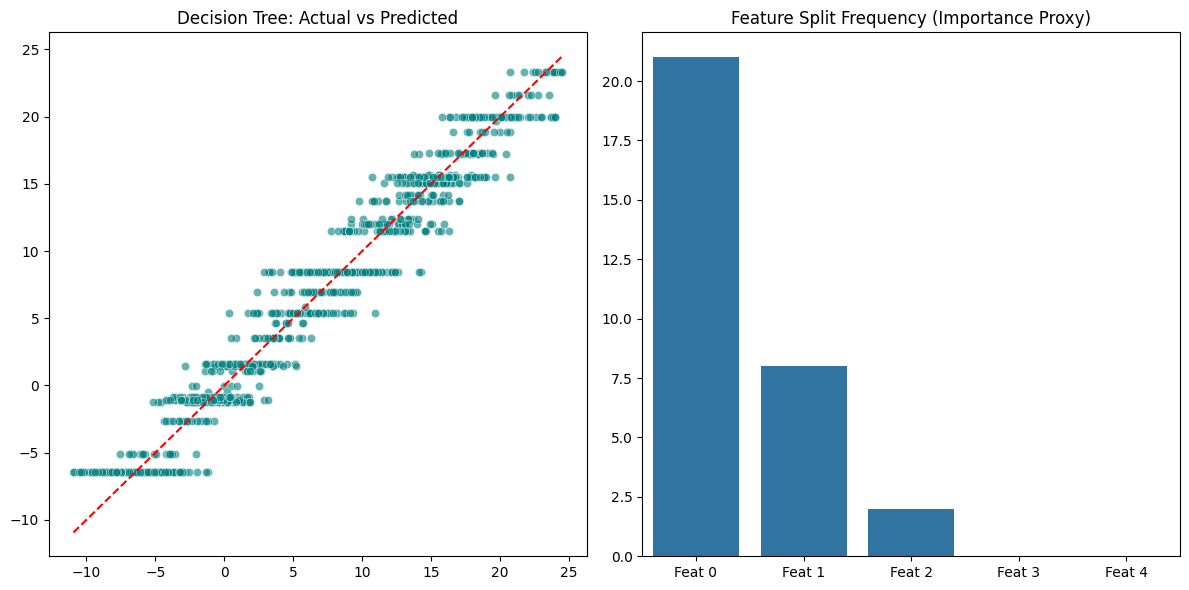

In [38]:
plt.figure(figsize=(12, 6))

# Actual vs Predicted Scatter
plt.subplot(1, 2, 1)
sns.scatterplot(x=y, y=y_pred, alpha=0.6, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Decision Tree: Actual vs Predicted")

# Feature Importance Visualization (Simple count based on splits)
def count_splits(node, features_dict):
    if node.value is not None: return
    features_dict[node.feature] += 1
    count_splits(node.left, features_dict)
    count_splits(node.right, features_dict)

importance = {i: 0 for i in range(5)}
count_splits(model.root, importance)

plt.subplot(1, 2, 2)
sns.barplot(x=[f"Feat {i}" for i in importance.keys()], y=list(importance.values()))
plt.title("Feature Split Frequency (Importance Proxy)")

plt.tight_layout()
plt.show()